<a href="https://colab.research.google.com/github/yashaswibastakoti/movie-recommender/blob/main/Movie_recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Content-based Movie Recommender

This notebook builds a content-based recommender using MovieLens (movies, ratings, tags)


In [2]:
# Importing libraries and loading the data
import pandas as pd
import numpy as np

In [3]:
movies = pd.read_csv("/content/data/movies.csv")
ratings = pd.read_csv("/content/data/ratings.csv")
tags = pd.read_csv("/content/data/tags.csv")

#check frist 5 rows of movies
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## EDA (Dataset Exploration / Analysis)


### Quick Look at the dataset

In [29]:
# Movies dataset
print("Movies dataset shape:", movies.shape)
print(movies.head())
print(movies.info())

# Ratings dataset
print("\nRatings dataset shape:", ratings.shape)
print(ratings.head())
print(ratings.info())

# Tags dataset
print("\nTags dataset shape:", tags.shape)
print(tags.head())
print(tags.info())


Movies dataset shape: (9742, 3)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure Animation Children Comedy Fantasy  
1                   Adventure Children Fantasy  
2                               Comedy Romance  
3                         Comedy Drama Romance  
4                                       Comedy  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None

Ratings dataset shape: (

### Lets check for missing values

In [16]:
print("Missing values in Movies dataset:\n", movies.isnull().sum())
print("\nMissing values in Ratings dataset:\n", ratings.isnull().sum())
print("\nMissing values in Tags dataset:\n", tags.isnull().sum())


Missing values in Movies dataset:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings dataset:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in Tags dataset:
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


### Lets look at the Rating distributions

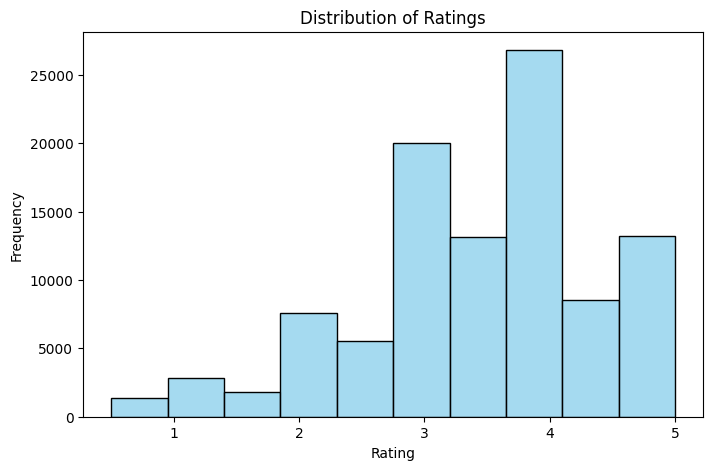

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=10, kde=False, color='skyblue')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


### Top-rated and most-rated movies

In [20]:
# Count the number of ratings per movie
rating_counts = ratings.groupby('movieId')['rating'].count().reset_index()
rating_counts.columns = ['movieId', 'rating_count']
rating_counts.head()


,movieId,rating_count
0,1,215
1,2,110
2,3,52
3,4,7
4,5,49


### merge with movies to see titles

In [21]:
top_rated_movies = rating_counts.merge(movies, on='movieId')
top_rated_movies = top_rated_movies.sort_values(by='rating_count', ascending=False).head(10)
top_rated_movies[['title', 'rating_count']]


,title,rating_count
314,Forrest Gump (1994),329
277,"Shawshank Redemption, The (1994)",317
257,Pulp Fiction (1994),307
510,"Silence of the Lambs, The (1991)",279
1938,"Matrix, The (1999)",278
224,Star Wars: Episode IV - A New Hope (1977),251
418,Jurassic Park (1993),238
97,Braveheart (1995),237
507,Terminator 2: Judgment Day (1991),224
461,Schindler's List (1993),220


### Average rating per movie

In [26]:
avg_ratings = ratings.groupby('movieId')['rating'].mean().reset_index()
avg_ratings.columns = ['movieId', 'average_rating']

top_avg_movies = avg_ratings.merge(movies, on='movieId')
top_avg_movies = top_avg_movies.sort_values(by='average_rating', ascending=False).head(10)
top_avg_movies[['title', 'average_rating']]


,title,average_rating
9693,Won't You Be My Neighbor? (2018),5.0
4667,Jane Eyre (1944),5.0
3802,Rain (2001),5.0
7927,Goodbye Charlie (1964),5.0
2934,Sorority House Massacre (1986),5.0
2933,Slumber Party Massacre III (1990),5.0
2932,Slumber Party Massacre II (1987),5.0
5015,True Stories (1986),5.0
9349,Moonlight,5.0
9347,Tom Segura: Mostly Stories (2016),5.0


### Popular Genres

/tmp/ipython-input-3281556280.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


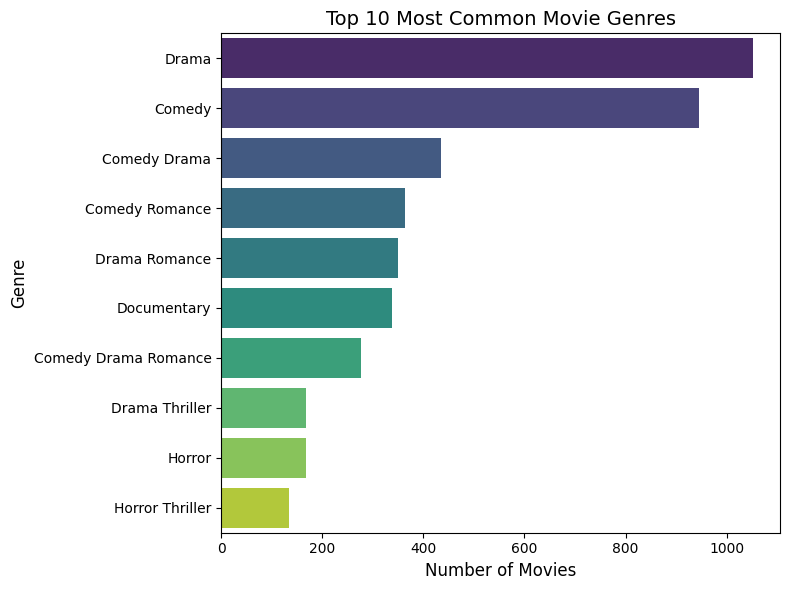

In [28]:
# Split genres and count each genre
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()

# Plot top 10 genres as a horizontal bar chart
top_genres = genre_counts.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title("Top 10 Most Common Movie Genres", fontsize=14)
plt.xlabel("Number of Movies", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()


### Top tags

/tmp/ipython-input-2503005084.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='magma')


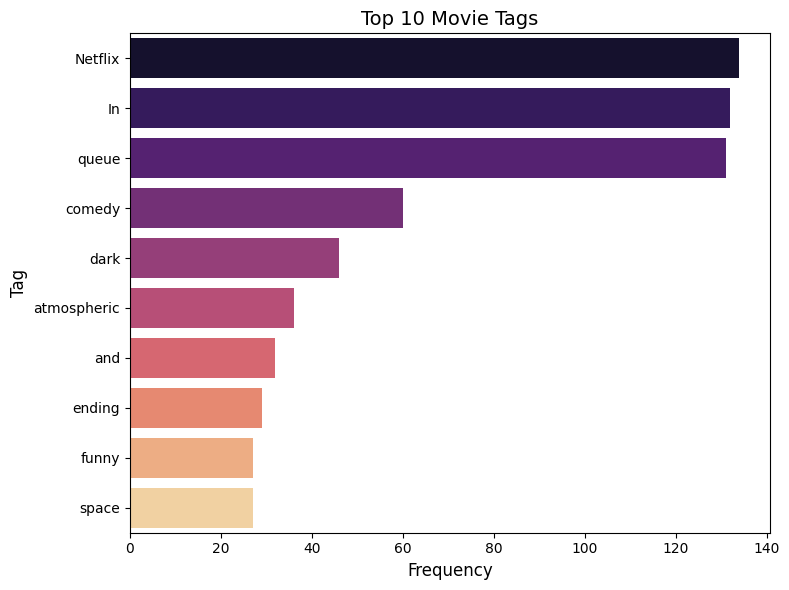

In [30]:
# Combine all tags per movie
tags['tag'] = tags['tag'].astype(str)
all_tags = tags['tag'].str.split(' ').explode()
tag_counts = all_tags.value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=tag_counts.values, y=tag_counts.index, palette='magma')
plt.title("Top 10 Movie Tags", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Tag", fontsize=12)
plt.tight_layout()
plt.show()


## Clean the genres
Since in movies.csv, genres are separated with "|" , we want to replace the "|" with spaces, so its easier to work with text.

In [4]:
# Clean the genres
movies['genres'] = movies['genres'].str.replace("|"," ")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


## Combine tags for each movie
The tags.csv file contains user-added tags for movies. We want all tags for each movie in one string.

In [5]:
tags['tag'] = tags['tag'].astype(str)

## Combine all tags per movie
movie_tags= tags.groupby('movieId')['tag'].apply(lambda x: " ".join(x)).reset_index()
movie_tags.head()

,movieId,tag
0,1,pixar pixar fun
1,2,fantasy magic board game Robin Williams game
2,3,moldy old
3,5,pregnancy remake
4,7,remake


## Now we need to merge movies with tags

In [6]:
# Merge movies with tags
movies_merged = movies.merge(movie_tags, on= 'movieId', how = 'left')

#Fill missing tags with empty string
movies_merged['tag'] = movies_merged['tag'].fillna("")
movies_merged.head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar pixar fun
1,2,Jumanji (1995),Adventure Children Fantasy,fantasy magic board game Robin Williams game
2,3,Grumpier Old Men (1995),Comedy Romance,moldy old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake


## Now create a combined content column
We need to merge title + genres + tags into one column.
This is what the recommender will use to compute similarity.

In [7]:
movies_merged['content'] = movies_merged['title'] + " " + movies_merged['genres'] + " " + movies_merged['tag']
movies_merged.head()


,movieId,title,genres,tag,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar pixar fun,Toy Story (1995) Adventure Animation Children ...
1,2,Jumanji (1995),Adventure Children Fantasy,fantasy magic board game Robin Williams game,Jumanji (1995) Adventure Children Fantasy fant...
2,3,Grumpier Old Men (1995),Comedy Romance,moldy old,Grumpier Old Men (1995) Comedy Romance moldy old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,,Waiting to Exhale (1995) Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,Father of the Bride Part II (1995) Comedy preg...


## Vectorize the movies
This is the heart of a content-based recommender.

### Import the vectorize
We will use TF-IDF vectorize from scikit-learn.
It conversts text (our content column) into a numeric matrix representing word importance.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer, remove common English stop words
tfidf = TfidfVectorizer(stop_words='english')


### Fit and transform the content

In [23]:
# Fit and transform the 'content' column
tfidf_matrix = tfidf.fit_transform(movies_merged['content'])

# Check the shape
tfidf_matrix.shape


(9742, 9949)

Here, Each row= one movie
      Each column = a word from the combined content
      
      -Numbers represent importance of that word for that movie

### Compute similarity

We use cosine similarity, which measures how similar two mobies are based on their content.

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between all movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Check shape
cosine_sim.shape


(9742, 9742)

This resullt is a matrix of size ( num_movies * num_movies)

Cosine_sim[i][j] tells us how similar movie i is to movie j.

### Create a reverse mapping ( title -> index)

We need a way top quickly find a movie by its title:

In [25]:
# Create a mapping from movie title to index
indices = pd.Series(movies_merged.index, index=movies_merged['title']).drop_duplicates()


## Create a recommendation function
This is where the recommender becomes interactive.

In [12]:
def recommend_movies(title, cosine_sim=cosine_sim, movies=movies_merged, indices=indices, top_n=5):
    # 1. Get the index of the movie that matches the title
    idx = indices[title]

    # 2. Get pairwise similarity scores for this movie with all others
    sim_scores = list(enumerate(cosine_sim[idx]))

    # 3. Sort the movies based on similarity scores (highest first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 4. Skip the first movie (itself) and get top N similar movies
    sim_scores = sim_scores[1:top_n+1]

    # 5. Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # 6. Return the top N most similar movies
    return movies['title'].iloc[movie_indices]


### Testing the recommender
Example 1

In [13]:
recommend_movies('Toy Story (1995)')


,title
2355,Toy Story 2 (1999)
1757,"Bug's Life, A (1998)"
7355,Toy Story 3 (2010)
3595,"Toy, The (1982)"
7039,Up (2009)


Example 2

In [14]:
recommend_movies('Jurassic Park (1993)')


,title
3409,Jurassic Park III (2001)
1164,"Lost World: Jurassic Park, The (1997)"
8590,Jurassic World (2015)
2539,We're Back! A Dinosaur's Story (1993)
2694,Dinosaur (2000)
